<a href="https://colab.research.google.com/github/MohamedKarimmm/Protein-Family-Classification/blob/main/k-mer%203%20and%204%20and%201-d%20cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install biopython pandas scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 45.7 MB/s eta 0:00:00


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta (3).gz to uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta (3).gz
Saving uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta (2).gz to uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta (2).gz
Saving uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta (1).gz to uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta (1).gz
Saving uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta.gz to uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta.gz


In [ ]:
print(uploaded.keys())

dict_keys(['uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta (3).gz', 'uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta (2).gz', 'uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta (1).gz', 'uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta.gz'])


In [ ]:
import gzip
import random
from Bio import SeqIO

file_names = [
'uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta.gz',
'uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta (1).gz',
'uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta (2).gz',
'uniprotkb_reviewed_true_AND_organism_id_2026_05_21.fasta (3).gz'
]

data=[]

labels=[
"kinase",
"protease",
"transporter",
"receptor"
]

for file,label in zip(file_names,labels):

    with gzip.open(file,'rt') as f:

        sequences=list(
            SeqIO.parse(
                f,
                "fasta"
            )
        )

        random.shuffle(
            sequences
        )

        sequences=sequences[:250]

        for seq in sequences:

            data.append(
                [
                    str(seq.seq),
                    label
                ]
            )

print("Total samples:",
      len(data))

print(data[:2])

Total samples: 1000
[['MAEEEETAALTEKVIRTQRVFINLLDSYSSGNIGKFLSNCVVGASLEEITEEEEEEDENKSAMLEASSTKVKEGTFQIVGTLSKPDSPRPDFAVETYSAISREDLLMRLLECDVIIYNITESSQQMEEAIWAVSALSEEVSHFEKRKLFILLSTVMTWARSKALDPEDSEVPFTEEDYRRRKSHPNFLDHINAEKMVLKFGKKARKFAAYVVAAGLQYGAEGGMLHTFFKMAWLGEIPALPVFGDGTNVIPTIHVLDLAGVIQNVIDHVPKPHYLVAVDESVHTLEDIVKCISKNTGPGKIQKIPRENAYLTKDLTQDCLDHLLVNLRMEALFVKENFNIRWAAQTGFVENINTILKEYKQSRGLMPIKICILGPPAVGKSSIAKELANYYKLHHIQLKDVISEAIAKLEAIVAPNDVGEGEEEVEEEEEEENVEDAQELLDGIKESMEQNAGQLDDQYIIRFMKEKLKSMPCRNQGYILDGFPKTYDQAKDLFNQEDEEEEDDVRGRMFPFDKLIIPEFVCALDASDEFLKERVINLPESIVAGTHYSQDRFLRALSNYRDINIDDETVFNYFDELEIHPIHIDVGKLEDAQNRLAIKQLIKEIGEPRNYGLTDEEKAEEERKAAEERLAREAAEEAEREHQEAVEMAEKIARWEEWNKRLEEVKREERELLEAQSIPLRNYLMTYVMPTLIQGLNECCNVRPEDPVDFLAEYLFKNNPEAQ', 'kinase'], ['MTHGEELGSDVHQDSIVLTYLEGLLMHQAAGGSGTAVDKKSAGHNEEDQNFNISGSAFPTCQSNGPVLNTHTYQGSGMLHLKKARLLQSSEDWNAAKRKRLSDSIMNLNVKKEALLAGMVDSVPKGKQDSTLLASLLQSFSSRLQTVALSQQIRQSLKEQGYALSHDSLKVEKDLRCYGVASSHLKTLLKKSKVKDQKPDTNLPDVTKNLIRDRFAESPHHVGQSGTKVMSEPLSCAA

In [ ]:
import pandas as pd

df=pd.DataFrame(
    data,
    columns=[
        "sequence",
        "label"
    ]
)

print(df.head())

print(df.shape)

                                            sequence   label
0  MAEEEETAALTEKVIRTQRVFINLLDSYSSGNIGKFLSNCVVGASL...  kinase
1  MTHGEELGSDVHQDSIVLTYLEGLLMHQAAGGSGTAVDKKSAGHNE...  kinase
2  MLLRSKPALPPPLMLLLLGPLGPLSPGALPRPAQAQDVVDLDFFTQ...  kinase
3  MAGPATQSPMKLMALQLLLWHSALWTVQEATPLGPASSLPQSFLLK...  kinase
4  MEEGGSTGSAGSDSSTSGSGGAQQRELERMAEVLVTGEQLRLRLHE...  kinase
(1000, 2)


In [ ]:
from collections import Counter

def get_kmers(sequence,k=4):

    return [sequence[i:i+k]
            for i in range(len(sequence)-k+1)]

all_kmers=[]

for seq in df["sequence"]:

    all_kmers.extend(get_kmers(seq))

top_kmers=[x[0]
            for x in Counter(all_kmers).most_common(1000)]

print("Number of kmers:",len(top_kmers))

Number of kmers: 1000


In [ ]:
def vectorize(sequence):

    kmers=get_kmers(sequence)

    counts=Counter(kmers)

    return [counts[k] for k in top_kmers]

X=df["sequence"].apply(vectorize)

X=pd.DataFrame(X.tolist())

y=df["label"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,accuracy_score

model=RandomForestClassifier(
    n_estimators=100
)

model.fit(X_train,y_train)

pred=model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,pred))

print(classification_report(
    y_test,
    pred
))

Accuracy: 0.35
              precision    recall  f1-score   support

      kinase       0.30      0.36      0.33        44
    protease       0.33      0.44      0.38        52
    receptor       0.29      0.18      0.23        49
 transporter       0.47      0.40      0.43        55

    accuracy                           0.35       200
   macro avg       0.35      0.35      0.34       200
weighted avg       0.35      0.35      0.35       200



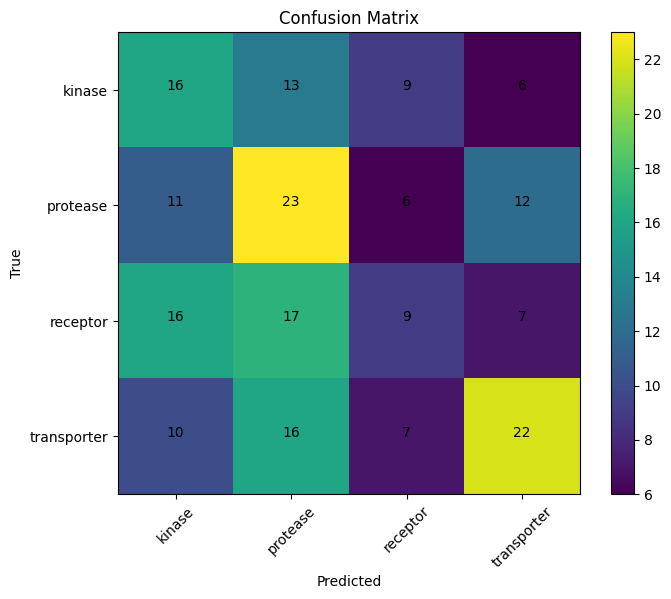

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test,pred)

labels=[
'kinase',
'protease',
'receptor',
'transporter'
]

plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
np.arange(len(labels)),
labels,
rotation=45
)

plt.yticks(
np.arange(len(labels)),
labels
)

plt.xlabel(
"Predicted"
)

plt.ylabel(
"True"
)

plt.title(
"Confusion Matrix"
)

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(
            j,
            i,
            cm[i,j],
            ha='center'
        )

plt.show()

In [ ]:
import pandas as pd

comparison = pd.DataFrame({

"Model":[
"Random Forest",
"Random Forest"
],

"k":[
3,
4
],

"Accuracy":[
0.375,
0.35
]

})

print(comparison)

           Model  k  Accuracy
0  Random Forest  3     0.375
1  Random Forest  4     0.350


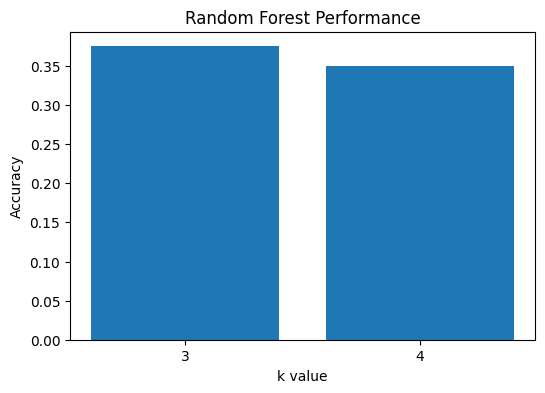

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
comparison["k"].astype(str),
comparison["Accuracy"]
)

plt.xlabel("k value")

plt.ylabel("Accuracy")

plt.title("Random Forest Performance")

plt.show()

In [1]:
!pip install biopython kagglehub tensorflow scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 47.6 MB/s eta 0:00:00


In [6]:
from google.colab import files

uploaded = files.upload()

Saving uniprotkb_accession_A0A009HHG3_OR_access_2026_06_04.fasta (1).gz to uniprotkb_accession_A0A009HHG3_OR_access_2026_06_04.fasta (1) (1).gz
Saving uniprotkb_accession_A0A009HHG3_OR_access_2026_06_04.fasta.gz to uniprotkb_accession_A0A009HHG3_OR_access_2026_06_04.fasta (2).gz
Saving uniprotkb_accession_A0A009HEB7_OR_access_2026_06_04.fasta.gz to uniprotkb_accession_A0A009HEB7_OR_access_2026_06_04.fasta (1).gz
Saving uniprotkb_reviewed_true_AND_organism_id_2026_06_04.fasta.gz to uniprotkb_reviewed_true_AND_organism_id_2026_06_04.fasta (1).gz


In [7]:
import os

for f in os.listdir():
    print(f)

.config
uniprotkb_accession_A0A009HEB7_OR_access_2026_06_04.fasta.gz
uniprotkb_reviewed_true_AND_organism_id_2026_06_04.fasta (1).gz
uniprotkb_accession_A0A009HEB7_OR_access_2026_06_04.fasta (1).gz
uniprotkb_reviewed_true_AND_organism_id_2026_06_04.fasta.gz
uniprotkb_accession_A0A009HHG3_OR_access_2026_06_04.fasta.gz
uniprotkb_accession_A0A009HHG3_OR_access_2026_06_04.fasta (2).gz
uniprotkb_accession_A0A009HHG3_OR_access_2026_06_04.fasta (1) (1).gz
uniprotkb_accession_A0A009HHG3_OR_access_2026_06_04.fasta (1).gz
sample_data


In [9]:
import gzip
from Bio import SeqIO

files = [
    "uniprotkb_accession_A0A009HHG3_OR_access_2026_06_04.fasta (1) (1).gz",
    "uniprotkb_reviewed_true_AND_organism_id_2026_06_04.fasta (1).gz",
    "uniprotkb_accession_A0A009HEB7_OR_access_2026_06_04.fasta.gz",
    "uniprotkb_accession_A0A009HHG3_OR_access_2026_06_04.fasta.gz"
]

for file in files:
    with gzip.open(file, "rt") as f:
        count = len(list(SeqIO.parse(f, "fasta")))
    print(file, "=", count)

uniprotkb_accession_A0A009HHG3_OR_access_2026_06_04.fasta (1) (1).gz = 100
uniprotkb_reviewed_true_AND_organism_id_2026_06_04.fasta (1).gz = 7891
uniprotkb_accession_A0A009HEB7_OR_access_2026_06_04.fasta.gz = 100
uniprotkb_accession_A0A009HHG3_OR_access_2026_06_04.fasta.gz = 100


In [25]:
import gzip
from Bio import SeqIO
import pandas as pd

data = []

# Kinase
with gzip.open("uniprotkb_accession_A0A009HHG3_OR_access_2026_06_04.fasta.gz","rt") as f:
    for seq in list(SeqIO.parse(f,"fasta"))[:100]:
        data.append([str(seq.seq),"kinase"])

# Protease
with gzip.open("uniprotkb_accession_A0A009HEB7_OR_access_2026_06_04.fasta.gz","rt") as f:
    for seq in list(SeqIO.parse(f,"fasta"))[:100]:
        data.append([str(seq.seq),"protease"])

# Transporter
with gzip.open("uniprotkb_accession_A0A009HHG3_OR_access_2026_06_04.fasta (1) (1).gz","rt") as f:
    for seq in list(SeqIO.parse(f,"fasta"))[:100]:
        data.append([str(seq.seq),"transporter"])

# Receptor
with gzip.open("uniprotkb_reviewed_true_AND_organism_id_2026_06_04.fasta (1).gz","rt") as f:
    for seq in list(SeqIO.parse(f,"fasta"))[:200]:
        data.append([str(seq.seq),"receptor"])

df = pd.DataFrame(
    data,
    columns=["sequence","label"]
)

print(df["label"].value_counts())
print(df.shape)

label
receptor       200
kinase         100
protease       100
transporter    100
Name: count, dtype: int64
(500, 2)


In [26]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

amino_acids = "ACDEFGHIKLMNPQRSTVWY"

char_to_int = {
    c:i+1
    for i,c in enumerate(amino_acids)
}

def encode_seq(seq):
    return [
        char_to_int.get(x,0)
        for x in seq
    ]

X_encoded = [
    encode_seq(seq)
    for seq in df["sequence"]
]

X = pad_sequences(
    X_encoded,
    maxlen=500,
    padding="post"
)

encoder = LabelEncoder()

y = encoder.fit_transform(
    df["label"]
)

print(X.shape)
print(y.shape)

(500, 500)
(500,)


In [28]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [29]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print(X_train.shape)
print(X_test.shape)

(400, 500, 1)
(100, 500, 1)


In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(
    Conv1D(
        32,
        3,
        activation="relu",
        input_shape=(500,1)
    )
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Conv1D(
        64,
        3,
        activation="relu"
    )
)

model.add(
    MaxPooling1D(2)
)

model.add(
    Flatten()
)

model.add(
    Dense(
        128,
        activation="relu"
    )
)

model.add(
    Dense(
        4,
        activation="softmax"
    )
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 498, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 249, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 247, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 123, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7872)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,007,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,014,596 (3.87 MB)

 Trainable params: 1,014,596 (3.87 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.4969 - loss: 2.3464 - val_accuracy: 0.5750 - val_loss: 1.8689
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6281 - loss: 0.9124 - val_accuracy: 0.5500 - val_loss: 1.0363
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7156 - loss: 0.7287 - val_accuracy: 0.5000 - val_loss: 0.9460
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7719 - loss: 0.5839 - val_accuracy: 0.5375 - val_loss: 0.9728
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8094 - loss: 0.4569 - val_accuracy: 0.5625 - val_loss: 1.0401
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8094 - loss: 0.3841 - val_accuracy: 0.5125 - val_loss: 1.2107
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8344 - loss: 0.3273 - val_accuracy: 0.5500 - val_loss: 1.2173
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8375 - loss: 0.3457 - val_accuracy: 0.5500 - 

In [32]:
loss,acc = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:",acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.5200 - loss: 1.2067
Test Accuracy: 0.5199999809265137


In [33]:
import numpy as np
from sklearn.metrics import classification_report

pred = model.predict(X_test)

pred = np.argmax(
    pred,
    axis=1
)

print(
    classification_report(
        y_test,
        pred
    )
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step
              precision    recall  f1-score   support

           0       0.16      0.20      0.18        20
           1       0.61      0.55      0.58        20
           2       0.90      0.90      0.90        40
           3       0.06      0.05      0.05        20

    accuracy                           0.52       100
   macro avg       0.43      0.42      0.43       100
weighted avg       0.53      0.52      0.52       100



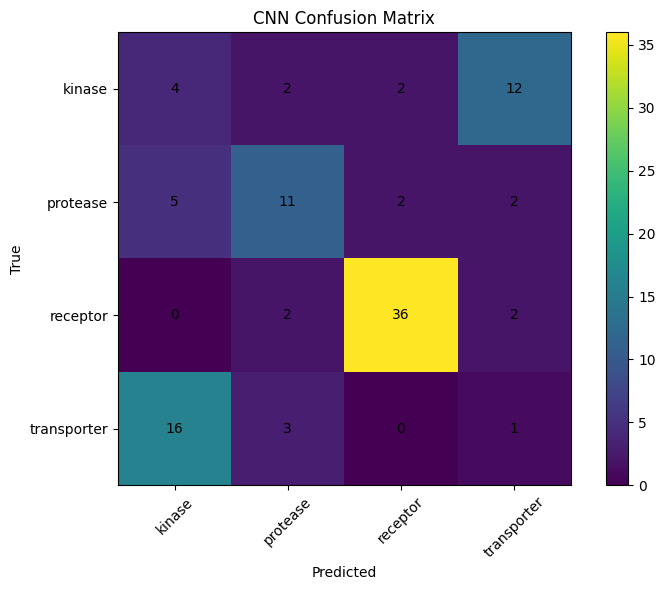

In [34]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

labels = ["kinase", "protease", "receptor", "transporter"]

cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    range(len(labels)),
    labels,
    rotation=45
)

plt.yticks(
    range(len(labels)),
    labels
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()